# Phase library comparison: ITO, Si3N4, TiO2 at 866 nm

Overlays the (period, radius, height) phase-library sweeps for three meta-atom materials on a 3x3 grid (materials by periods). Each panel plots phase span vs tooth radius, one curve per swept height, with a dashed line at the 1x2pi target. Phase span scales as (n-1)*k*h*fill, so TiO2 reaches 2pi first at fab-friendly geometry.

Batches reload from the Tidy3D local cache, no new FlexCredits. The TiO2 unit-cell sweep is in ../unit_cell/metalens_unit_cell_tio2_sweepP.ipynb.

Note: the ITO curve uses a lossless placeholder n=1.5147. Real ITO at 866 nm is n~1.90 with absorption, so the "ITO never reaches 2pi" reading below is an artifact of the wrong index. See docs/THEORY.md section 8.

In [ ]:
# --- repo-root bootstrap: makes data/ paths resolve from any notebook location ---
import os
from pathlib import Path
_root = Path.cwd()
while _root != _root.parent and not (_root / '.git').is_dir():
    _root = _root.parent
if (_root / '.git').is_dir():
    os.chdir(_root)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
import tidy3d.web as web

# === Shared simulation parameters (identical to all three sweepP notebooks) ===
lda0 = 0.866
freq0 = td.C_0 / lda0
fwidth = freq0 / 10.0

t_clad_lower = 5.0
t_clad_upper = 5.0
z_sub_top = 0.0
z_source = z_sub_top + t_clad_lower
z_clad_top = z_source + t_clad_upper

buffer_top = 2.0 * lda0
buffer_bot = 1.0 * lda0
z_min_sim = z_sub_top - buffer_bot

pol_angle = 0.0
inf_eff = 1e3
co_pol = 'p' if np.isclose(pol_angle, 0.0) else 's'

# Materials
Si = td.material_library['cSi']['Palik_Lossy']
SiO2 = td.material_library['SiO2']['Palik_Lossless']
ITO  = td.Medium(permittivity=1.5147 ** 2)
SiN  = td.Medium(permittivity=2.0   ** 2)
TiO2 = td.Medium(permittivity=2.4   ** 2)

# Sweep grid (same as all three sweepP notebooks)
P_list = np.array([0.30, 0.40, 0.50])
h_list = np.array([0.20, 0.40, 0.60, 0.80])
n_r = 8

def r_list_for_P(P_val, n=n_r, gap=0.02):
    return np.linspace(0.04, P_val / 2 - gap, n)

# Stack pieces that are invariant across (material, P, r, h)
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-inf_eff, -inf_eff, -inf_eff),
        rmax=( inf_eff,  inf_eff, z_sub_top)),
    medium=Si, name='Si_substrate')

cladding = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-inf_eff, -inf_eff, z_sub_top),
        rmax=( inf_eff,  inf_eff, z_clad_top)),
    medium=SiO2, name='SiO2_cladding')

source = td.PlaneWave(
    center=(0, 0, z_source),
    size=(td.inf, td.inf, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    direction='+', pol_angle=pol_angle, name='plane_wave')

boundary_spec = td.BoundarySpec(
    x=td.Boundary.periodic(),
    y=td.Boundary.periodic(),
    z=td.Boundary(minus=td.PML(), plus=td.PML()))

def make_sim(medium, tooth_name, P, r, h):
    z_tooth_top = z_clad_top + h
    z_max = z_tooth_top + buffer_top
    Lz    = z_max - z_min_sim
    z_ctr = 0.5 * (z_min_sim + z_max)
    tooth = td.Structure(
        geometry=td.Cylinder(
            center=(0, 0, z_clad_top + h/2),
            radius=r, length=h, axis=2),
        medium=medium, name=tooth_name)
    mon_t = td.DiffractionMonitor(
        center=(0, 0, z_tooth_top + 0.5*lda0),
        size=(td.inf, td.inf, 0), freqs=[freq0],
        normal_dir='+', name='t_orders')
    mon_flux_t = td.FluxMonitor(
        center=(0, 0, z_tooth_top + 0.5*lda0),
        size=(td.inf, td.inf, 0), freqs=[freq0], name='flux_t')
    mon_flux_r = td.FluxMonitor(
        center=(0, 0, z_source - 0.5*lda0),
        size=(td.inf, td.inf, 0), freqs=[freq0], name='flux_r')
    return td.Simulation(
        center=(0, 0, z_ctr), size=(P, P, Lz),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=25, wavelength=lda0),
        structures=[substrate, cladding, tooth],
        sources=[source],
        monitors=[mon_t, mon_flux_t, mon_flux_r],
        run_time=td.RunTimeSpec(quality_factor=1),
        boundary_spec=boundary_spec)

# === Load all three batches (should hit Tidy3D's local cache and return instantly) ===
material_configs = [
    ('ito',   'ITO',           ITO,  'ITO_tooth',  1.5147),
    ('si3n4', r'Si$_3$N$_4$',  SiN,  'SiN_tooth',  2.0),
    ('tio2',  'TiO$_2$',       TiO2, 'TiO2_tooth', 2.4),
]

all_data = {}
for tag, label, medium, tooth_name, n_val in material_configs:
    print(f'Loading {tag} batch from cache...')
    sims = {
        f'{tag}_sweepP_P_{P_val:.3f}_r_{r:.4f}_h_{h:.4f}':
            make_sim(medium, tooth_name, P_val, r, h)
        for P_val in P_list
        for r in r_list_for_P(P_val)
        for h in h_list
    }
    batch = web.Batch(simulations=sims, verbose=False)
    batch_results = batch.run(path_dir='data')

    data_per_P = {}
    for P_val in P_list:
        r_vals = r_list_for_P(P_val)
        t = np.zeros((len(r_vals), len(h_list)), dtype=complex)
        for i, r in enumerate(r_vals):
            for j, h in enumerate(h_list):
                sd = batch_results[f'{tag}_sweepP_P_{P_val:.3f}_r_{r:.4f}_h_{h:.4f}']
                amp_00 = sd['t_orders'].amps.sel(
                    f=freq0, polarization=co_pol, orders_x=0, orders_y=0)
                t[i, j] = complex(amp_00.values)
        phase = np.unwrap(np.angle(t), axis=0)
        phase -= phase[0:1, :]
        data_per_P[float(P_val)] = dict(r=r_vals, t=t, phase=phase)
    all_data[tag] = dict(label=label, n=n_val, data_per_P=data_per_P)
    print(f'  {tag} loaded ({len(sims)} sims)')

print('\nAll three batches loaded.')

Loading ito batch from cache...


12:25:17 Pacific Daylight Time WARNING: Simulation final field decay value of   
                               2.74e-05 is greater than the simulation shutoff  
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Simulation final field decay value of   
                               2.99e-05 is greater than the simulation shutoff  
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Simulation final field decay value of   
                               2.39e-05 is greater than the simulation shutoff  
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Simulation final field decay value of   
                               2.63e-05 is greater than the simulation shutoff  
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

...

12:26:13 Pacific Daylight Time WARNING: Simulation final field decay value of   
                               0.00804 is greater than the simulation shutoff   
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Simulation final field decay value of   
                               0.00721 is greater than the simulation shutoff   
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Simulation final field decay value of   
                               0.0217 is greater than the simulation shutoff    
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Simulation final field decay value of   
                               0.00895 is greater than the simulation shutoff   
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

  tio2 loaded (96 sims)

All three batches loaded.


## The 3x3 figure

Rows are material (ITO, Si3N4, TiO2, increasing index). Columns are period (P = 300, 400, 500 nm). Curves are tooth height h in {200, 400, 600, 800} nm. The dashed red line at phase/2pi = 1 is the full-2pi target. The y-axis is shared across panels so the (n-1) and h scaling reads directly. The x-axis is shared per column since r_max = P/2 - 20 nm grows with P.

Saved phase_library_comparison.png


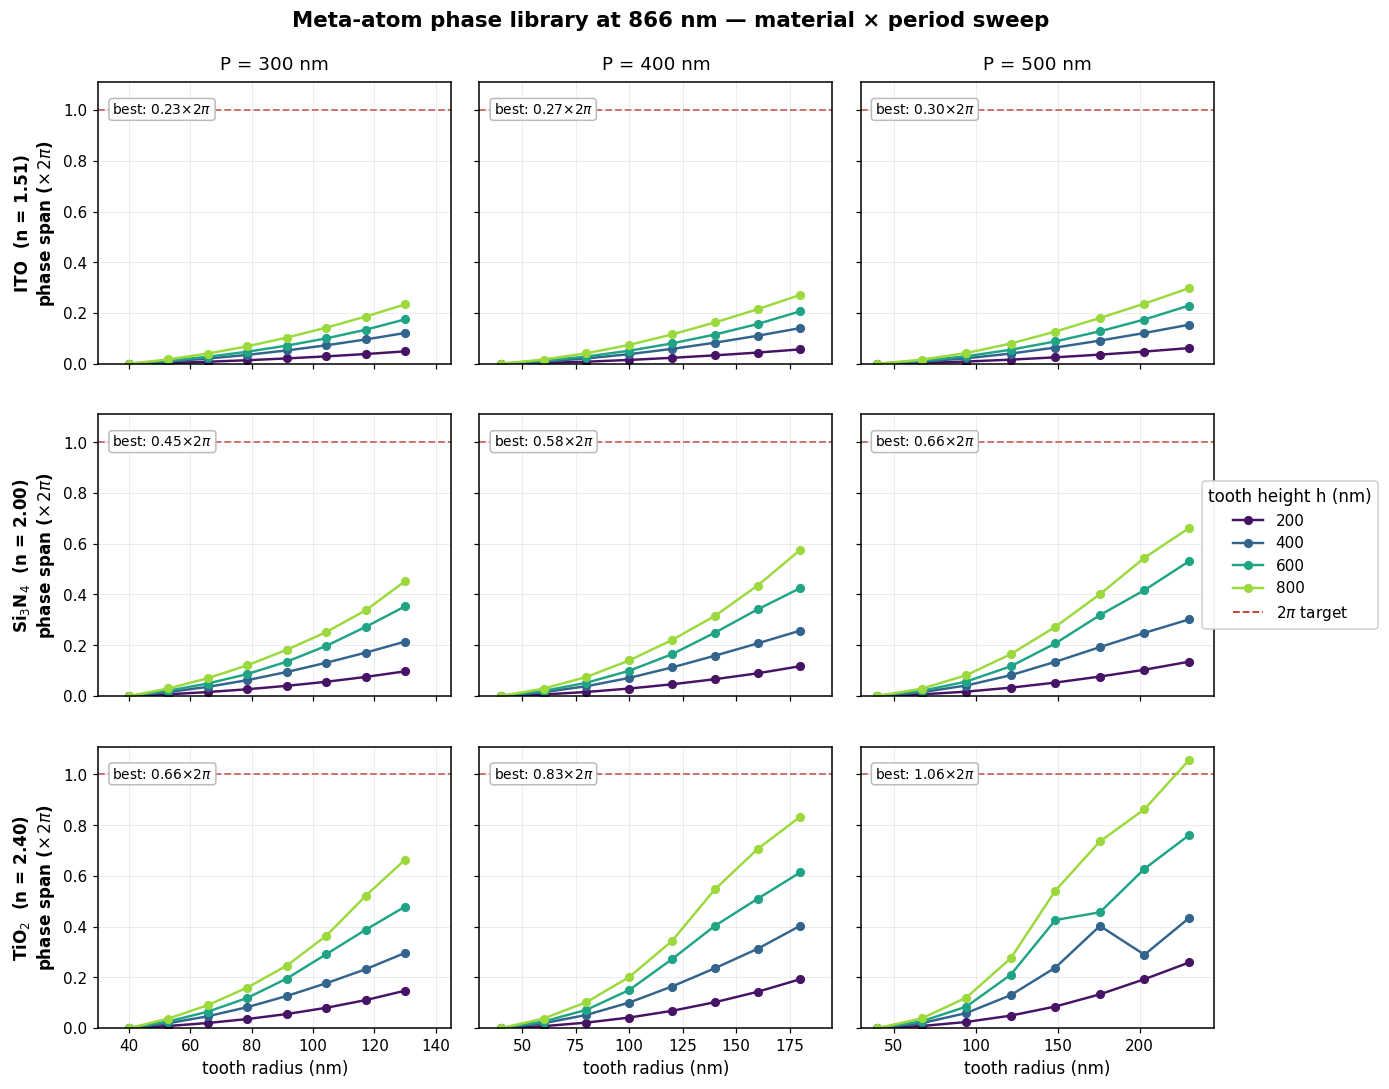

In [2]:
# === Publication-style 3x3 grid ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.6,
    'lines.markersize': 5,
    'axes.linewidth': 1.0,
    'figure.dpi': 110,
})

fig, axes = plt.subplots(3, 3, figsize=(13, 10),
                         sharex='col', sharey='all')
colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(h_list)))

# Global y-limit: span largest observed value with headroom for the 2π line
ymax = max(
    d['phase'][-1, j] / (2*np.pi)
    for entry in all_data.values()
    for d in entry['data_per_P'].values()
    for j in range(len(h_list))
)
ylim_top = max(1.1, ymax * 1.05)

tag_order = ['ito', 'si3n4', 'tio2']
for row, tag in enumerate(tag_order):
    entry = all_data[tag]
    label, data_per_P, n_val = entry['label'], entry['data_per_P'], entry['n']
    for col, P_val in enumerate(P_list):
        ax = axes[row, col]
        d = data_per_P[float(P_val)]
        for j, h in enumerate(h_list):
            ax.plot(d['r'] * 1e3, d['phase'][:, j] / (2 * np.pi),
                    '-o', color=colors[j], label=f'{int(h*1e3)}')
        ax.axhline(1.0, ls='--', color='#c0392b', lw=1.2, alpha=0.8, zorder=0)
        ax.grid(alpha=0.25, linewidth=0.6)
        ax.set_ylim(0, ylim_top)
        ax.set_xlim(30, d['r'][-1] * 1e3 + 15)
        # Column titles on the top row
        if row == 0:
            ax.set_title(f'P = {int(P_val*1e3)} nm', pad=8)
        # Row labels on the leftmost column
        if col == 0:
            ax.set_ylabel(
                f'{label}  (n = {n_val:.2f})\n'
                + r'phase span ($\times\,2\pi$)',
                fontweight='bold')
        # x-axis label on the bottom row
        if row == 2:
            ax.set_xlabel('tooth radius (nm)')
        # Annotate best-cell value with text in upper-left
        best_span = max(
            (d['phase'][-1, j] - d['phase'][0, j]) / (2*np.pi)
            for j in range(len(h_list))
        )
        ax.text(0.04, 0.93, f'best: {best_span:.2f}'+r'$\times 2\pi$',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='#bbb', boxstyle='round,pad=0.25'),
                verticalalignment='top')

# Single shared legend on the right
handles, labels_ = axes[0, 0].get_legend_handles_labels()
# Add the 2π-target reference line to the legend
ref_line = plt.Line2D([], [], color='#c0392b', ls='--', lw=1.2,
                       label=r'1$\,\times\,2\pi$ target')
handles_with_ref = handles + [ref_line]
labels_with_ref = labels_ + [r'2$\pi$ target']
fig.legend(handles_with_ref, labels_with_ref,
           title='tooth height h (nm)', loc='center right',
           bbox_to_anchor=(0.995, 0.5), borderaxespad=0,
           frameon=True, framealpha=0.95)

fig.suptitle('Meta-atom phase library at 866 nm, material × period sweep',
             fontsize=14, fontweight='bold', y=0.995)

plt.subplots_adjust(left=0.10, right=0.88, top=0.93, bottom=0.07,
                    hspace=0.18, wspace=0.08)

# Save publication-quality copy
import os as _os; _os.makedirs('figures', exist_ok=True)
out_path = 'figures/phase_library_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'Saved {out_path}')
plt.show()

## Reading the figure

- Rows: at fixed (P, h) the span scales with (n-1). ITO at h=800 nm is close to SiN at h=400 nm and TiO2 at h=300 nm.
- Columns: widening P from 300 to 500 nm lifts each curve about 30-50% from fill fraction.
- Only TiO2 at the largest h and widest P crosses the 2pi target, matching (n-1)*k*h*fill ~ 2pi. SiN reaches 0.66x2pi there, ITO much less (and its curve uses the placeholder index, see the intro).

The 'best:' callout is the maximum phase span across radii in that (material, P) cell.